# 🚢 Titanic - Machine Learning from Disaster

## Phase 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the Titanic training dataset and identify patterns associated with passenger survival.

Exploratory Data Analysis (EDA) helps us move beyond simply understanding the structure and quality of the data. In this phase, we investigate how individual passenger characteristics and combinations of features relate to the target variable, `Survived`.

In this notebook, we will:

* Review the cleaned training dataset.
* Analyze the distribution of the target variable.
* Explore categorical features such as `Sex`, `Pclass`, and `Embarked`.
* Examine numerical features such as `Age`, `Fare`, `SibSp`, and `Parch`.
* Compare feature distributions between survivors and non-survivors.
* Investigate interactions between important passenger characteristics.
* Explore family-related patterns using temporary analytical features.
* Examine correlations between numerical variables.
* Perform selected statistical tests to support visual observations.
* Revisit missing-value patterns in the context of survival.
* Translate EDA findings into an actionable feature-engineering plan.

## 1. Import Libraries

We begin by importing the libraries required for data manipulation, visualization, and statistical analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

For exploratory analysis, we will use the minimally cleaned training dataset created during Phase 2.

In [3]:
train = pd.read_csv(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/processed/train_clean.csv"
)

df = train.copy()

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (891, 12)


In [4]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Dataset Check

Before beginning EDA, we confirm that the dataset contains the expected passenger features and the `Survived` target variable.

Missing values that remain in features such as `Age` and `Cabin` are intentional. Their treatment was deferred because additional information discovered during EDA and feature engineering may support better preprocessing decisions.

# 3. Target Variable Analysis

The target variable for this competition is `Survived`, where:

* `0` = Passenger did not survive.
* `1` = Passenger survived.

Before investigating predictor variables, we first examine the target distribution.

In [7]:
survival_summary = (
    df["Survived"]
    .value_counts()
    .sort_index()
    .to_frame(name="Count")
)

survival_summary["Percentage"] = (
    survival_summary["Count"] / len(df) * 100
).round(2)

survival_summary.index = [
    "Did Not Survive",
    "Survived"
]

survival_summary

,Count,Percentage
Did Not Survive,549,61.62
Survived,342,38.38


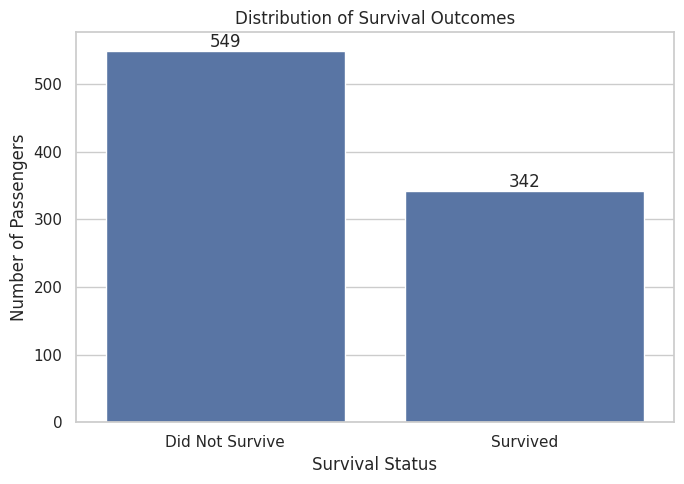

In [8]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Distribution of Survival Outcomes")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Did Not Survive", "Survived"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [9]:
majority_baseline = (
    df["Survived"]
    .value_counts(normalize=True)
    .max()
)

print(
    f"Majority-class baseline accuracy: "
    f"{majority_baseline:.2%}"
)

Majority-class baseline accuracy: 61.62%


### Interpretation

The target distribution shows that the two survival classes are not equally represented.

Passengers who did not survive form the majority class, while survivors represent a smaller proportion of the training data.

The imbalance is noticeable but not so extreme that specialized imbalance-handling techniques are automatically required.

The majority-class proportion provides a simple baseline. A useful machine learning model should perform meaningfully better than a strategy that predicts the majority class for every passenger.

### Modeling Implication

Accuracy remains a reasonable primary metric because it matches the Titanic competition evaluation metric. However, during model evaluation we should also inspect the confusion matrix and class-specific performance to understand the types of errors being made.

# 4. Categorical Features and Survival

We will begin by investigating categorical passenger characteristics.

The primary features examined in this section are:

* `Sex`
* `Pclass`
* `Embarked`

### 4.1 Sex vs Survival

#### Question

**Was passenger sex associated with the probability of survival?**

We will compare the number of survivors and non-survivors among male and female passengers and calculate the survival rate within each group.


In [12]:
sex_survival = (
    df.groupby("Sex")["Survived"]
    .agg(
        Passenger_Count="count",
        Survivors="sum",
        Survival_Rate="mean"
    )
)

sex_survival["Survival_Rate"] = (
    sex_survival["Survival_Rate"] * 100
).round(2)

sex_survival

,Passenger_Count,Survivors,Survival_Rate
Sex,,,
female,314,233,74.20
male,577,109,18.89


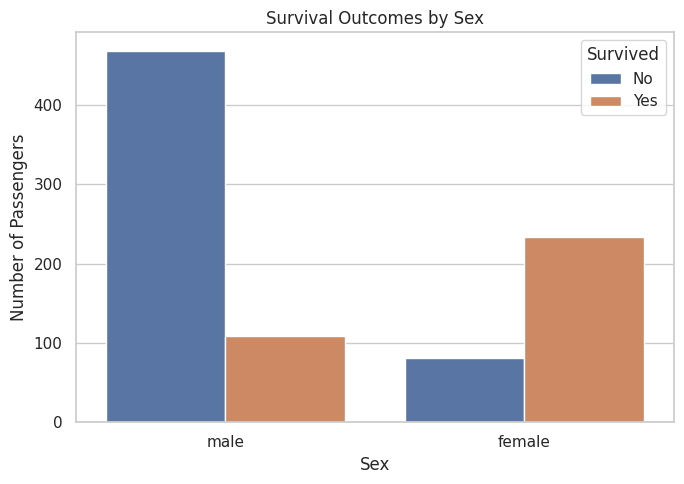

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival Outcomes by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()

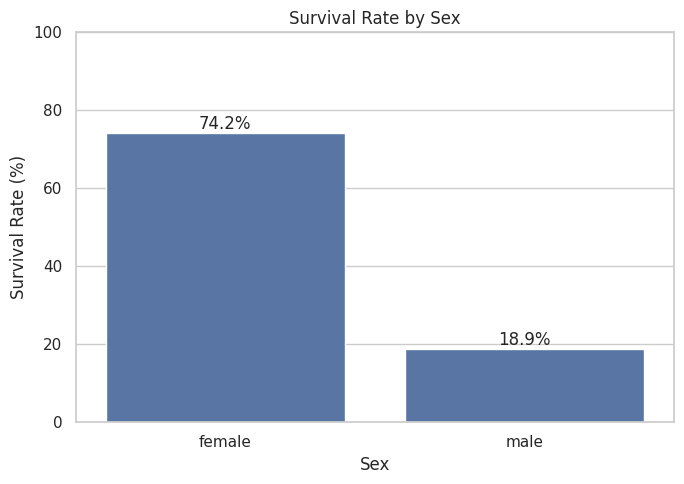

In [14]:
plt.figure(figsize=(7, 5))

sex_rates = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="Survival_Rate")
)

ax = sns.barplot(
    data=sex_rates,
    x="Sex",
    y="Survival_Rate"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Interpretation

The survival rates show a substantial difference between male and female passengers.

This suggests that `Sex` contains strong predictive information about survival and should be retained as an important feature for machine learning.

However, sex should not be considered in isolation. Later sections will investigate whether its relationship with survival changes across passenger class and age groups.

### Feature Engineering Implication

* Retain `Sex` as a core predictor.
* Investigate interactions between `Sex`, `Pclass`, and `Age`.

### 4.2 Passenger Class vs Survival

#### Question

**Was passenger class associated with survival?**

`Pclass` represents socioeconomic and travel-class differences between passengers.

We will compare survival rates across first, second, and third class.


In [15]:
class_survival = (
    df.groupby("Pclass")["Survived"]
    .agg(
        Passenger_Count="count",
        Survivors="sum",
        Survival_Rate="mean"
    )
)

class_survival["Survival_Rate"] = (
    class_survival["Survival_Rate"] * 100
).round(2)

class_survival

,Passenger_Count,Survivors,Survival_Rate
Pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24


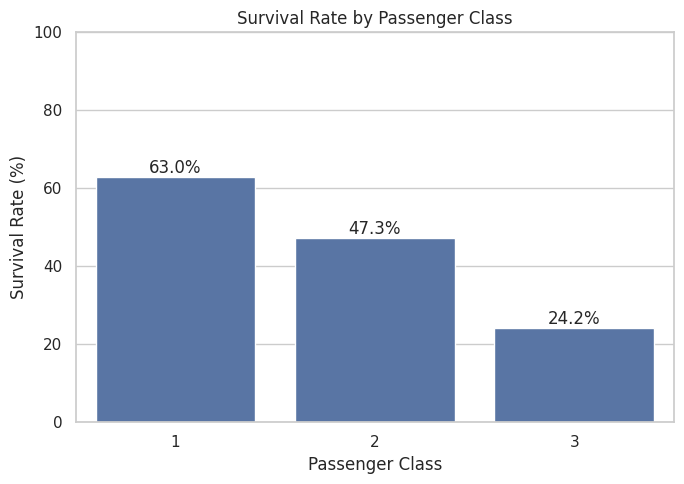

In [16]:
plt.figure(figsize=(7, 5))

class_rates = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="Survival_Rate")
)

ax = sns.barplot(
    data=class_rates,
    x="Pclass",
    y="Survival_Rate"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Interpretation

Survival rates differ across passenger classes, indicating that socioeconomic or travel-class differences were associated with survival outcomes.

Because passenger class may also be related to fare, cabin location, and embarkation port, some of these variables may contain overlapping information.

### Feature Engineering Implication

* Retain `Pclass`.
* Investigate `Pclass × Sex`.
* Investigate the relationship between `Pclass` and `Fare`.
* Investigate whether cabin information provides additional information beyond passenger class.


### 4.3 Embarkation Port vs Survival

#### Question

**Did survival rates differ according to the passenger's port of embarkation?**

The `Embarked` feature contains three categories:

* `C` — Cherbourg
* `Q` — Queenstown
* `S` — Southampton

Any observed relationship should be interpreted carefully because embarkation port may also be associated with passenger class and fare.


In [19]:
embarked_survival = (
    df.groupby("Embarked")["Survived"]
    .agg(
        Passenger_Count="count",
        Survivors="sum",
        Survival_Rate="mean"
    )
)

embarked_survival["Survival_Rate"] = (
    embarked_survival["Survival_Rate"] * 100
).round(2)

embarked_survival

,Passenger_Count,Survivors,Survival_Rate
Embarked,,,
C,168,93,55.36
Q,77,30,38.96
S,646,219,33.90


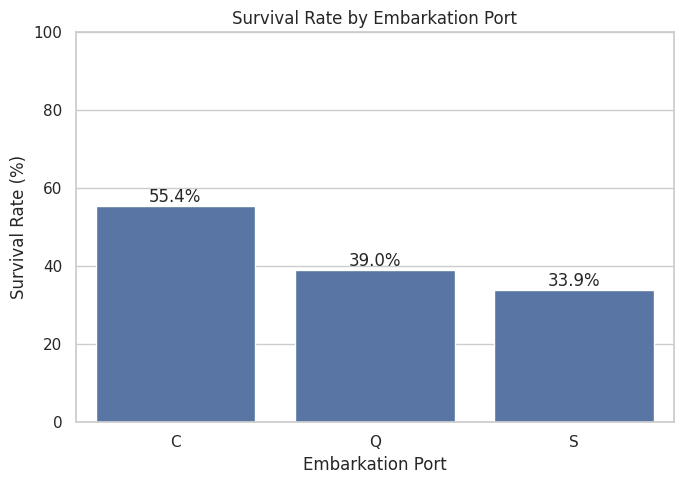

In [20]:
plt.figure(figsize=(7, 5))

embarked_rates = (
    df.groupby("Embarked")["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="Survival_Rate")
)

ax = sns.barplot(
    data=embarked_rates,
    x="Embarked",
    y="Survival_Rate"
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

In [21]:
embarked_class = pd.crosstab(
    df["Embarked"],
    df["Pclass"],
    normalize="index"
).mul(100).round(2)

embarked_class

Pclass,1,2,3
Embarked,,,
C,50.60,10.12,39.29
Q,2.60,3.90,93.51
S,19.97,25.39,54.64


### Interpretation

Survival rates vary across embarkation ports.

However, the passenger-class composition also differs across ports. Therefore, the observed relationship between `Embarked` and survival may partly reflect differences in socioeconomic status rather than an independent effect of embarkation port itself.

### Modeling Implication

`Embarked` should initially be retained as a predictor. Model validation can later determine whether it contributes useful information after other features such as `Pclass`, `Fare`, and `Sex` are included.


# 5. Statistical Association of Categorical Features

Visual differences do not necessarily imply that two variables have a statistically meaningful association.

For categorical variables, we can use the **Chi-square test of independence** to evaluate whether the observed distribution of survival differs significantly across feature categories.

We will test:

* `Sex` vs `Survived`
* `Pclass` vs `Survived`
* `Embarked` vs `Survived`

### Hypotheses

**Null Hypothesis (H₀):**

The feature and survival are independent.

**Alternative Hypothesis (H₁):**

There is an association between the feature and survival.

A small p-value provides evidence against the null hypothesis.


In [23]:
def chi_square_test(df, feature, target="Survived"):
    contingency_table = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = (
        stats.chi2_contingency(
            contingency_table
        )
    )

    return {
        "Feature": feature,
        "Chi-Square": round(chi2, 4),
        "Degrees of Freedom": dof,
        "P-Value": p_value
    }


chi_results = pd.DataFrame([
    chi_square_test(df, "Sex"),
    chi_square_test(df, "Pclass"),
    chi_square_test(df, "Embarked")
])

chi_results

,Feature,Chi-Square,Degrees of Freedom,P-Value
0,Sex,260.7170,1,1.197357e-58
1,Pclass,102.8890,2,4.549252e-23
2,Embarked,25.9645,2,2.300863e-06


### Interpretation

The Chi-square results provide statistical evidence about whether each categorical feature is associated with survival.

Features with small p-values show evidence of an association with the target variable.

However, statistical significance should not be confused with predictive importance. A feature may be statistically associated with survival while providing little additional information once stronger correlated features are already included in a model.

The final value of each feature will therefore be evaluated through cross-validation.

## 6. Age and Survival

### Question

**How does passenger age relate to survival?**

`Age` is a continuous numerical feature with missing values.

Rather than immediately converting age into fixed categories, we will first compare the raw age distributions of survivors and non-survivors.

We will examine:

* Distribution shape.
* Median and mean age.
* Differences between survival groups.
* Potential nonlinear relationships.

Missing ages will be excluded from age-specific visualizations rather than imputed solely for EDA.


In [25]:
age_summary = (
    df.groupby("Survived")["Age"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

age_summary

,Count,Mean,Median,Std,Min,Max
Survived,,,,,,
0,424,30.63,28.0,14.17,1.00,74.0
1,290,28.34,28.0,14.95,0.42,80.0


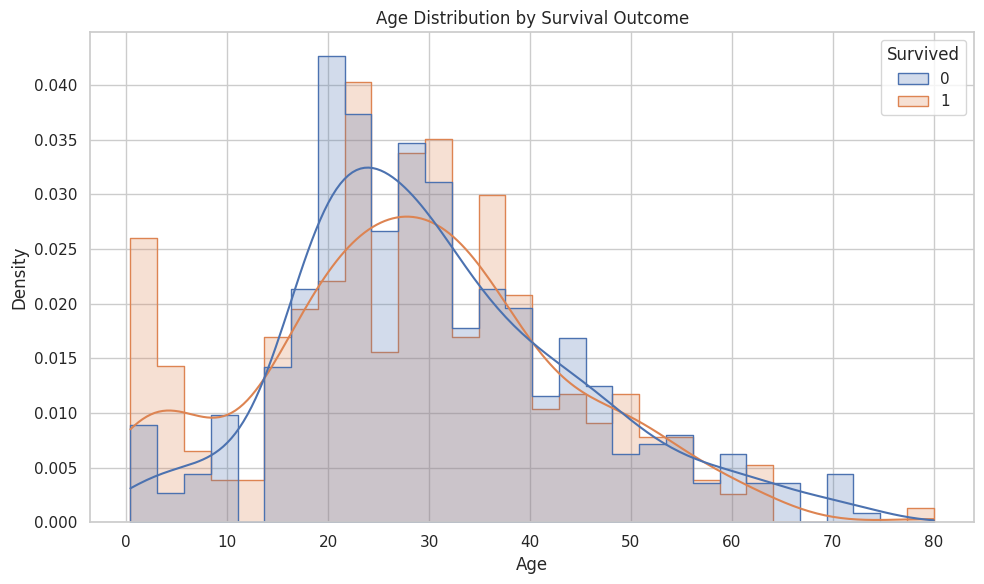

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Age Distribution by Survival Outcome"
)
plt.xlabel("Age")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

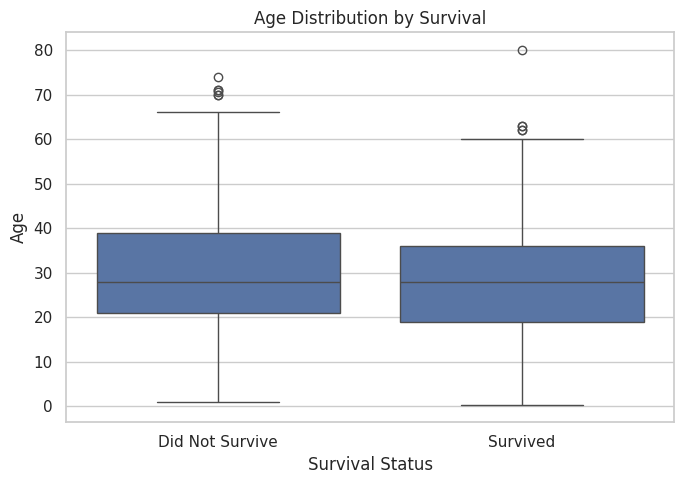

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.tight_layout()
plt.show()

## 6.1 Temporary Age Groups for Exploration

The relationship between age and survival may be nonlinear.

For example, very young passengers may have experienced different survival outcomes from adults, even if the overall mean age difference between survivors and non-survivors is small.

To explore this possibility, we will create temporary age groups.

These categories are used only for visualization and hypothesis generation. The final age-group definitions, if used at all, will be evaluated during feature engineering.


In [29]:
df["AgeGroup_EDA"] = pd.cut(
    df["Age"],
    bins=[
        0,
        12,
        18,
        30,
        50,
        65,
        np.inf
    ],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Older Adult",
        "Senior"
    ],
    include_lowest=True
)

age_group_summary = (
    df.groupby(
        "AgeGroup_EDA",
        observed=False
    )["Survived"]
    .agg(
        Passenger_Count="count",
        Survival_Rate="mean"
    )
)

age_group_summary["Survival_Rate"] = (
    age_group_summary["Survival_Rate"]
    .mul(100)
    .round(2)
)

age_group_summary

,Passenger_Count,Survival_Rate
AgeGroup_EDA,,
Child,69,57.97
Teen,70,42.86
Young Adult,270,35.56
Adult,241,42.32
Older Adult,56,37.50
Senior,8,12.50


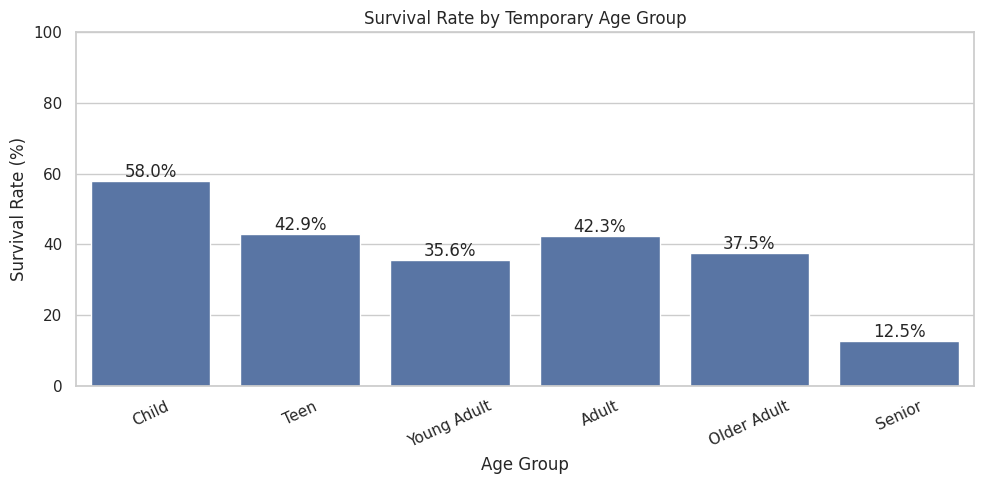

In [30]:
plt.figure(figsize=(10, 5))

age_group_plot = (
    age_group_summary
    .reset_index()
)

ax = sns.barplot(
    data=age_group_plot,
    x="AgeGroup_EDA",
    y="Survival_Rate"
)

plt.title("Survival Rate by Temporary Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Interpretation

The raw age distributions and temporary age-group analysis can reveal patterns that may not be visible from a simple correlation coefficient.

If survival varies substantially across specific age ranges, this suggests that the relationship between age and survival may be nonlinear.

### Feature Engineering Implication

Potential approaches to evaluate later include:

* Retaining continuous `Age`.
* Creating an `IsChild` indicator.
* Creating age bands.
* Allowing tree-based models to learn nonlinear age thresholds automatically.


# 7. Fare and Survival

### Question

**Was the fare paid by a passenger associated with survival?**

`Fare` is a continuous numerical feature that may contain information about socioeconomic status, passenger class, cabin quality, and group ticket purchases.

The distribution is highly right-skewed, so we will examine both the raw distribution and a logarithmic transformation for visualization.


In [33]:
fare_summary = (
    df.groupby("Survived")["Fare"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

fare_summary

,Count,Mean,Median,Std,Min,Max
Survived,,,,,,
0,549,22.12,10.5,31.39,0.0,263.00
1,342,48.40,26.0,66.60,0.0,512.33


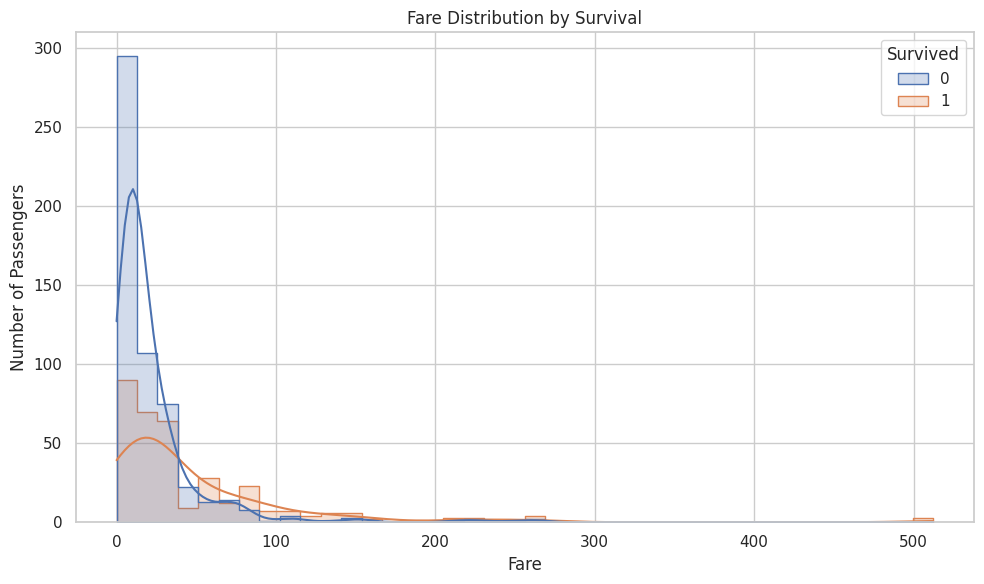

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Fare",
    hue="Survived",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

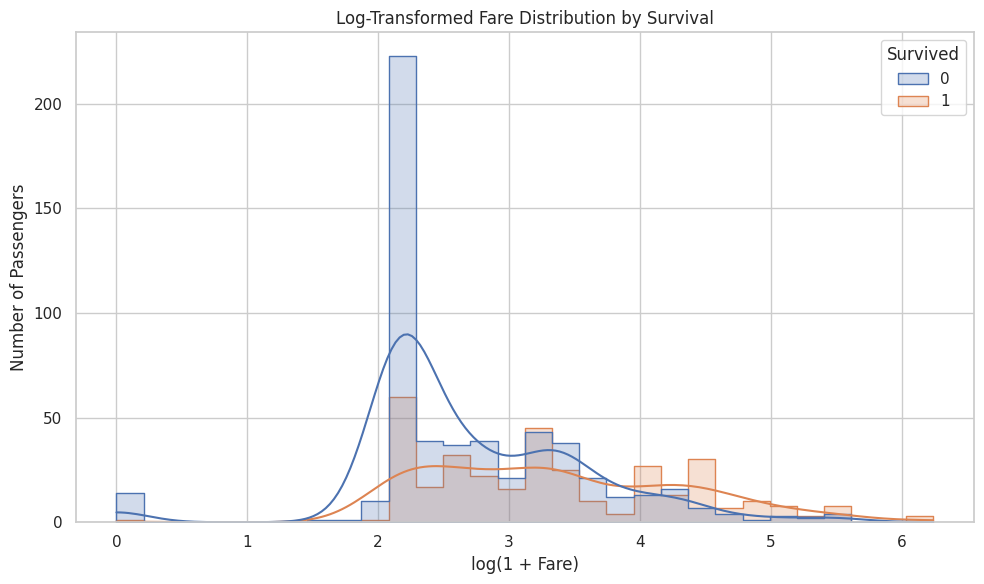

In [35]:
df["LogFare_EDA"] = np.log1p(
    df["Fare"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="LogFare_EDA",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title(
    "Log-Transformed Fare Distribution "
    "by Survival"
)
plt.xlabel("log(1 + Fare)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

### Interpretation

Fare distributions differ between survival groups, suggesting that ticket price contains useful information related to survival.

However, fare should not automatically be interpreted as an independent causal factor. It is strongly connected to passenger class and may also represent shared or group tickets.

The strong right skew in the raw fare distribution also suggests that a logarithmic transformation may be worth evaluating during modeling.

### Feature Engineering Implication

Potential experiments include:

* Raw `Fare`.
* Log-transformed `Fare`.
* Fare bands.
* Fare per passenger within a shared ticket group.


# 8. Family Relationships and Survival

The Titanic dataset contains two family-related variables:

* `SibSp` — Number of siblings or spouses aboard.
* `Parch` — Number of parents or children aboard.

Individually, these features may not fully represent a passenger's family situation.

In [38]:
sibsp_summary = (
    df.groupby("SibSp")["Survived"]
    .agg(
        Passenger_Count="count",
        Survival_Rate="mean"
    )
)

sibsp_summary["Survival_Rate"] = (
    sibsp_summary["Survival_Rate"]
    .mul(100)
    .round(2)
)

sibsp_summary

,Passenger_Count,Survival_Rate
SibSp,,
0,608,34.54
1,209,53.59
2,28,46.43
3,16,25.00
4,18,16.67
5,5,0.00
8,7,0.00


In [39]:
parch_summary = (
    df.groupby("Parch")["Survived"]
    .agg(
        Passenger_Count="count",
        Survival_Rate="mean"
    )
)

parch_summary["Survival_Rate"] = (
    parch_summary["Survival_Rate"]
    .mul(100)
    .round(2)
)

parch_summary

,Passenger_Count,Survival_Rate
Parch,,
0,678,34.37
1,118,55.08
2,80,50.00
3,5,60.00
4,4,0.00
5,5,20.00
6,1,0.00


## 8.1 Temporary Family Size Analysis

A passenger's total family group aboard the Titanic can be approximated using:

`FamilySize = SibSp + Parch + 1`

The additional `1` represents the passenger.

We will create this feature temporarily to investigate whether travelling alone, with a small family, or with a large family was associated with different survival outcomes.


In [40]:
df["FamilySize_EDA"] = (
    df["SibSp"] +
    df["Parch"] +
    1
)

family_summary = (
    df.groupby("FamilySize_EDA")["Survived"]
    .agg(
        Passenger_Count="count",
        Survivors="sum",
        Survival_Rate="mean"
    )
)

family_summary["Survival_Rate"] = (
    family_summary["Survival_Rate"]
    .mul(100)
    .round(2)
)

family_summary

,Passenger_Count,Survivors,Survival_Rate
FamilySize_EDA,,,
1,537,163,30.35
2,161,89,55.28
3,102,59,57.84
4,29,21,72.41
5,15,3,20.00
6,22,3,13.64
7,12,4,33.33
8,6,0,0.00
11,7,0,0.00


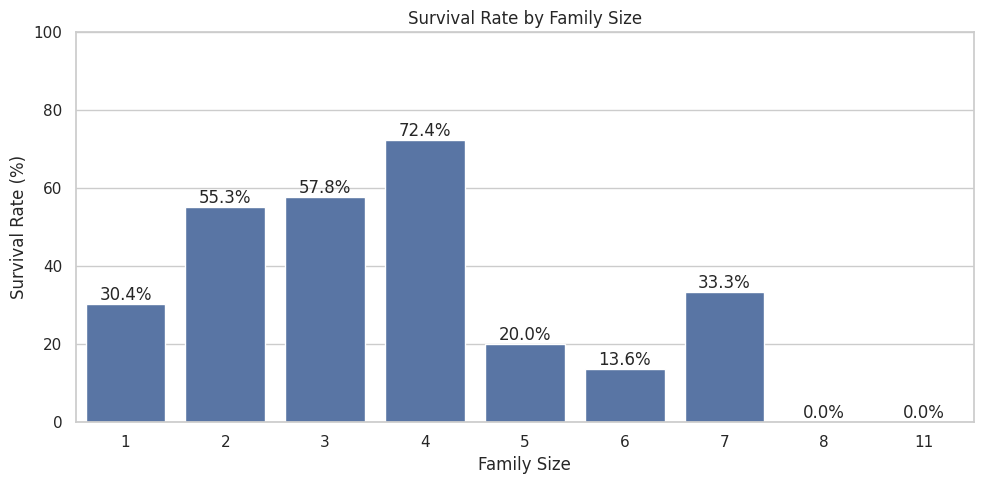

In [41]:
plt.figure(figsize=(10, 5))

family_plot = (
    family_summary
    .reset_index()
)

ax = sns.barplot(
    data=family_plot,
    x="FamilySize_EDA",
    y="Survival_Rate"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Interpretation

The relationship between family size and survival appears more informative than examining `SibSp` and `Parch` independently.

The pattern may also be nonlinear. Travelling alone and travelling in a very large family may have different outcomes from travelling with a small family group.

However, family-size categories with very few passengers should be interpreted cautiously because extreme survival rates may be caused by small sample sizes.

### Feature Engineering Implication

The following features should be evaluated during Phase 4:

* `FamilySize`
* `IsAlone`
* Potential family-size categories

Any category boundaries should be treated as hypotheses and validated rather than assumed to be optimal.


# 9. Multivariate Analysis

Individual features may not fully explain survival patterns.

Machine learning models often benefit from interactions where the effect of one feature depends on another feature.

We will investigate several important combinations identified during the earlier analysis.

## 9.1 Sex × Passenger Class

### Question

**Did the relationship between sex and survival differ across passenger classes?**

This interaction is particularly important because both `Sex` and `Pclass` individually show strong relationships with survival.


In [42]:
sex_class_survival = pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
).mul(100).round(2)

sex_class_survival

Pclass,1,2,3
Sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


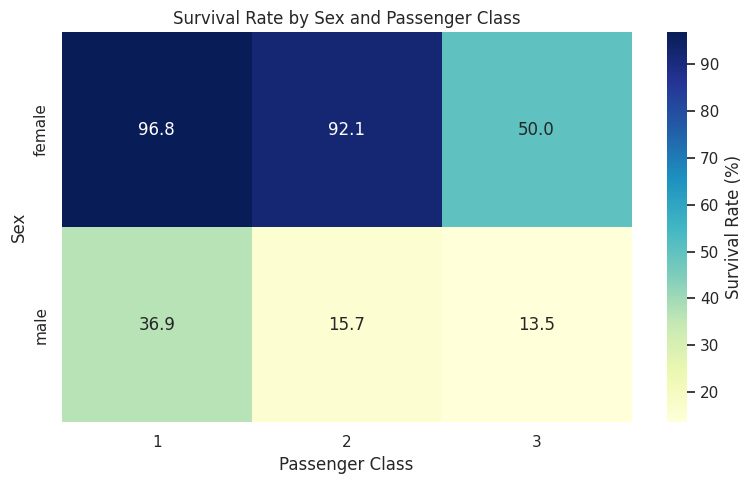

In [43]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    sex_class_survival,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={
        "label": "Survival Rate (%)"
    }
)

plt.title(
    "Survival Rate by Sex and Passenger Class"
)

plt.xlabel("Passenger Class")
plt.ylabel("Sex")

plt.tight_layout()
plt.show()

### Interpretation

The combined analysis shows that survival outcomes cannot be fully explained by either sex or passenger class alone.

The relationship between sex and survival varies across passenger classes, demonstrating an important interaction between these variables.

### Modeling Implication

Tree-based models may capture this interaction automatically.

For linear models such as Logistic Regression, explicitly testing interaction terms may improve performance.

This interaction should therefore be considered during model experimentation.


## 9.2 Age × Sex

### Question

**Did the relationship between age and survival differ between male and female passengers?**

We will use the temporary age groups created earlier to investigate this interaction.

Because some groups may contain relatively few passengers, both survival rates and sample sizes should be considered when interpreting the results.


In [44]:
age_sex_summary = (
    df.groupby(
        ["AgeGroup_EDA", "Sex"],
        observed=False
    )["Survived"]
    .agg(
        Passenger_Count="count",
        Survival_Rate="mean"
    )
)

age_sex_summary["Survival_Rate"] = (
    age_sex_summary["Survival_Rate"]
    .mul(100)
    .round(2)
)

age_sex_summary

Passenger_Count  Survival_Rate
AgeGroup_EDA Sex                                   
Child        female               32          59.38
             male                 37          56.76
Teen         female               36          75.00
             male                 34           8.82
Young Adult  female               90          75.56
             male                180          15.56
Adult        female               86          77.91
             male                155          22.58
Older Adult  female               17          94.12
             male                 39          12.82
Senior       female                0            NaN
             male                  8          12.50

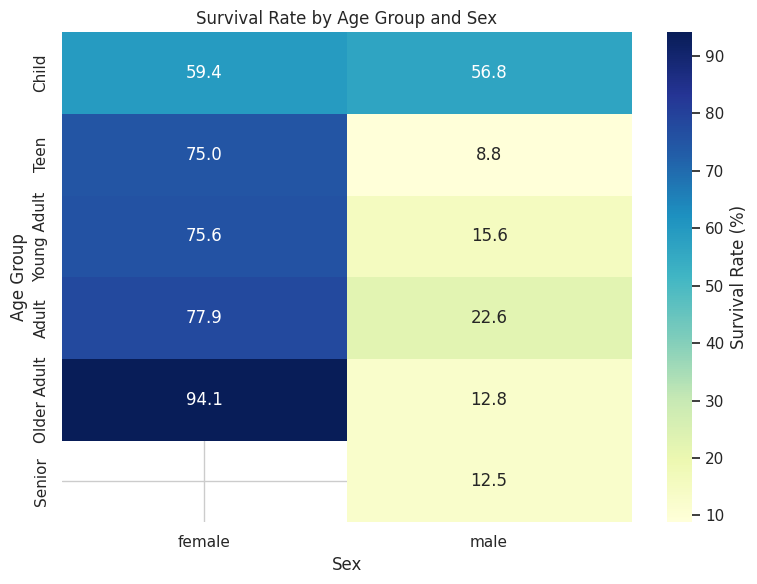

In [45]:
age_sex_pivot = pd.pivot_table(
    df,
    values="Survived",
    index="AgeGroup_EDA",
    columns="Sex",
    aggfunc="mean",
    observed=False
).mul(100)

plt.figure(figsize=(8, 6))

sns.heatmap(
    age_sex_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={
        "label": "Survival Rate (%)"
    }
)

plt.title(
    "Survival Rate by Age Group and Sex"
)
plt.xlabel("Sex")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

### Interpretation

The interaction between age and sex provides additional information beyond examining either variable independently.

Age may be particularly useful for identifying specific passenger groups whose survival patterns differ from the broader pattern associated with sex.

### Feature Engineering Implication

Potential features to evaluate include:

* `IsChild`
* Age groups
* `Sex × Age` interactions

These should be evaluated carefully because age is incomplete and requires an appropriate imputation strategy.


## 9.3 Fare × Passenger Class

### Question

**Does fare contain useful information beyond passenger class?**

Because fare and passenger class are related, we will examine fare distributions separately within each passenger class.

If fare still differs between survivors and non-survivors within the same class, it may provide information beyond `Pclass` alone.


In [47]:
fare_class_summary = (
    df.groupby(
        ["Pclass", "Survived"]
    )["Fare"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
    .round(2)
)

fare_class_summary

Count   Mean  Median
Pclass Survived                      
1      0            80  64.68   44.75
       1           136  95.61   77.96
2      0            97  19.41   13.00
       1            87  22.06   21.00
3      0           372  13.67    8.05
       1           119  13.69    8.52

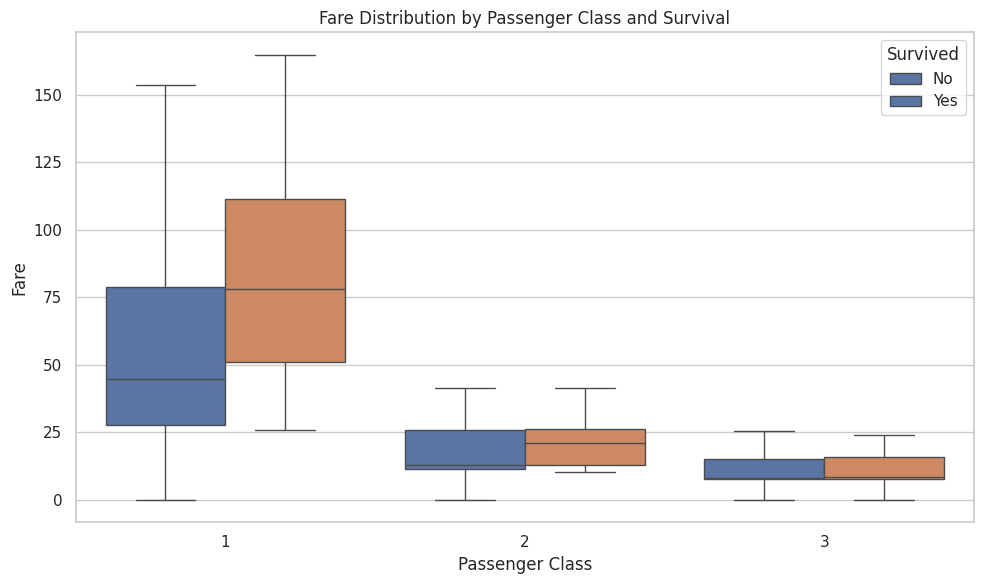

In [48]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Survived",
    showfliers=False
)

plt.title(
    "Fare Distribution by Passenger Class "
    "and Survival"
)
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()

### Interpretation

Analyzing fare within each passenger class helps determine whether `Fare` provides information beyond the broad socioeconomic grouping represented by `Pclass`.

Differences within the same passenger class would support retaining both variables.

However, fare may also represent group-ticket pricing, meaning that raw fare may not always correspond to the amount paid by one individual passenger.

### Feature Engineering Implication

Investigate:

* `Fare`
* `LogFare`
* Shared ticket groups
* `FarePerPerson`

The usefulness of each representation should be evaluated through cross-validation.


# 10. Correlation Analysis

A correlation matrix provides a compact view of linear relationships between numerical variables.

We will examine:

* `Survived`
* `Pclass`
* `Age`
* `SibSp`
* `Parch`
* `Fare`
* Temporary `FamilySize_EDA`

Correlation values should be interpreted carefully.

A weak correlation does not necessarily mean that a feature is useless for prediction. Relationships may be nonlinear, categorical, or dependent on interactions with other features.


In [49]:
correlation_features = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize_EDA"
]

correlation_matrix = (
    df[correlation_features]
    .corr()
)

correlation_matrix.round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize_EDA
Survived,1.00,-0.34,-0.08,-0.04,0.08,0.26,0.02
Pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55,0.07
Age,-0.08,-0.37,1.00,-0.31,-0.19,0.10,-0.30
SibSp,-0.04,0.08,-0.31,1.00,0.41,0.16,0.89
Parch,0.08,0.02,-0.19,0.41,1.00,0.22,0.78
Fare,0.26,-0.55,0.10,0.16,0.22,1.00,0.22
FamilySize_EDA,0.02,0.07,-0.30,0.89,0.78,0.22,1.00


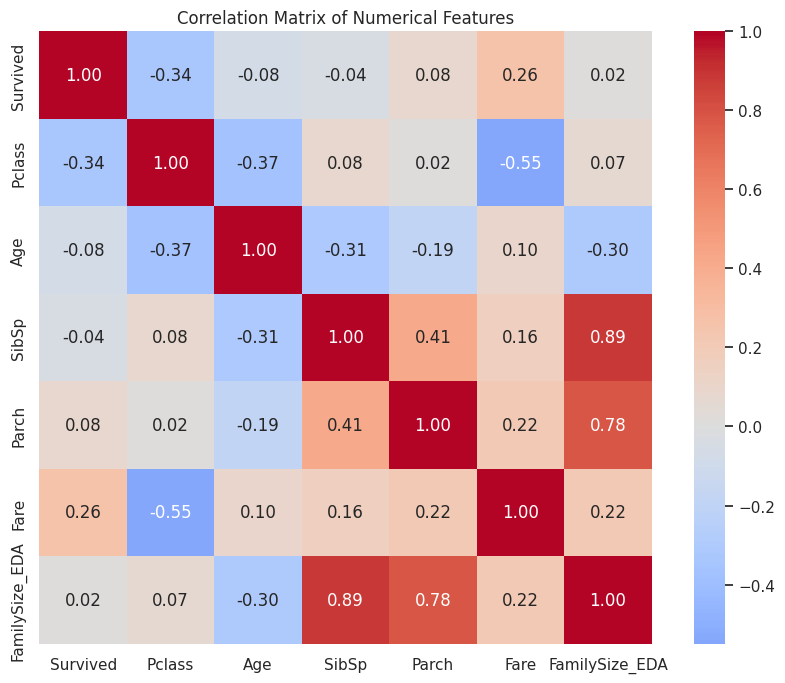

In [50]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.tight_layout()
plt.show()

In [51]:
survival_correlations = (
    correlation_matrix["Survived"]
    .drop("Survived")
    .sort_values(
        key=abs,
        ascending=False
    )
)

survival_correlations

Pclass           -0.338481
Fare              0.257307
Parch             0.081629
Age              -0.077221
SibSp            -0.035322
FamilySize_EDA    0.016639
Name: Survived, dtype: float64

### Interpretation

The correlation matrix highlights linear relationships between numerical variables and survival.

However, several important limitations should be remembered:

* `Sex` is not included because it is categorical.
* `Pclass` is numerically encoded but conceptually ordinal.
* Nonlinear relationships may have weak Pearson correlations.
* Interaction effects are not captured.
* Correlation does not imply causation.

Therefore, correlation should be used as one exploratory tool rather than as the sole basis for feature selection.


# 11. Statistical Comparison of Numerical Features

To complement the visual analysis, we will compare selected numerical features between survivors and non-survivors using the **Mann–Whitney U test**.

This non-parametric test does not require the variables to follow a normal distribution and is therefore suitable for skewed variables such as `Fare`.

### Hypotheses

**Null Hypothesis (H₀):**

The distributions of the feature are the same between survivors and non-survivors.

**Alternative Hypothesis (H₁):**

The feature distributions differ between the two survival groups.

As with the Chi-square test, statistical significance does not guarantee predictive usefulness.


In [53]:
def mann_whitney_test(
    df,
    feature,
    target="Survived"
):
    group_0 = (
        df.loc[
            df[target] == 0,
            feature
        ]
        .dropna()
    )

    group_1 = (
        df.loc[
            df[target] == 1,
            feature
        ]
        .dropna()
    )

    statistic, p_value = (
        stats.mannwhitneyu(
            group_0,
            group_1,
            alternative="two-sided"
        )
    )

    return {
        "Feature": feature,
        "Statistic": round(
            statistic,
            2
        ),
        "P-Value": p_value
    }

In [54]:
numerical_test_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize_EDA"
]

mann_whitney_results = pd.DataFrame([
    mann_whitney_test(
        df,
        feature
    )
    for feature in numerical_test_features
])

mann_whitney_results

,Feature,Statistic,P-Value
0,Age,65278.0,1.604925e-01
1,Fare,57806.5,4.553477e-22
2,SibSp,85775.0,8.016684e-03
3,Parch,82385.0,3.712491e-05
4,FamilySize_EDA,77659.0,7.970801e-07


### Interpretation

The Mann–Whitney U tests indicate which numerical features show statistically detectable distributional differences between survivors and non-survivors.

These results should be considered together with:

* Effect size.
* Visual patterns.
* Feature interactions.
* Missing data.
* Cross-validation performance.

A statistically significant feature may still provide limited incremental predictive value, while a feature with a complex nonlinear relationship may be useful even when a simple statistical comparison appears weak.


# 12. Missing Information as a Potential Signal

During the data-quality audit, we identified substantial missingness in `Cabin` and `Age`.

In this section, we investigate whether the **presence or absence of recorded information** is associated with survival.

This does not prove why the values are missing or establish a formal missing-data mechanism.

However, if missingness itself is associated with the target, binary indicators such as `CabinKnown` or `AgeKnown` may be useful candidate features.

These indicators will be created temporarily for analysis.

In [56]:
df["CabinKnown_EDA"] = (
    df["Cabin"]
    .notna()
    .astype(int)
)

df["AgeKnown_EDA"] = (
    df["Age"]
    .notna()
    .astype(int)
)

missingness_survival = pd.DataFrame({
    "Cabin Known": (
        df.groupby(
            "CabinKnown_EDA"
        )["Survived"]
        .mean()
        .mul(100)
    ),
    "Age Known": (
        df.groupby(
            "AgeKnown_EDA"
        )["Survived"]
        .mean()
        .mul(100)
    )
})

missingness_survival.round(2)

,Cabin Known,Age Known
0,29.99,29.38
1,66.67,40.62


In [57]:
cabin_known_summary = (
    df.groupby(
        "CabinKnown_EDA"
    )["Survived"]
    .agg(
        Passenger_Count="count",
        Survival_Rate="mean"
    )
)

cabin_known_summary[
    "Survival_Rate"
] = (
    cabin_known_summary[
        "Survival_Rate"
    ]
    .mul(100)
    .round(2)
)

cabin_known_summary

,Passenger_Count,Survival_Rate
CabinKnown_EDA,,
0,687,29.99
1,204,66.67


### Interpretation

The availability of certain passenger information may itself contain useful predictive information.

For example, cabin information may be related to passenger class, ticket type, or record quality. Therefore, an association between cabin availability and survival should not automatically be interpreted as a direct causal effect.

### Feature Engineering Implication

Potential features to evaluate include:

* `CabinKnown`
* `Deck`
* Possibly `AgeKnown`

These features should be tested through cross-validation before being included in the final model.

# 13. EDA Findings and Modeling Implications

The exploratory analysis identified several passenger characteristics and interactions that may be useful for predicting survival.

### Important Principle

These findings generate **feature-engineering hypotheses**.

They do not prove that every proposed feature will improve the final model.

Each engineered feature should be evaluated using a consistent cross-validation strategy before being accepted into the final feature set.


# 14. Phase 3 Summary

In this notebook, we performed exploratory data analysis to understand how passenger characteristics relate to survival.

## What We Analyzed

### Target Variable

We examined the distribution of `Survived` and confirmed the majority-class baseline established during Phase 1.

### Categorical Features

We investigated:

* `Sex`
* `Pclass`
* `Embarked`

We also used Chi-square tests to evaluate statistical associations between categorical variables and survival.

### Numerical Features

We examined:

* `Age`
* `Fare`
* `SibSp`
* `Parch`

Distribution plots and summary statistics were used to compare survivors and non-survivors.

Mann–Whitney U tests were used as an additional statistical comparison for selected numerical variables.

### Family Structure

We temporarily combined `SibSp` and `Parch` into `FamilySize_EDA` and observed that family structure may contain information that is not captured by either variable independently.

### Multivariate Relationships

We investigated important interactions including:

* `Sex × Pclass`
* `Age × Sex`
* `Fare × Pclass`

These analyses demonstrated that survival patterns are often more complex than simple one-feature relationships.

### Missing Information

We explored whether the availability of `Cabin` and `Age` information was associated with survival and identified missingness indicators as potential feature-engineering candidates.